# Quantium Virtual Internship — Task 2
## Experimentation and Uplift Testing

Evaluate the performance of a store trial conducted in stores **77, 86, and 88** by identifying suitable control stores and testing whether the trial layouts produced a statistically significant uplift in sales and customer numbers.

**Sections:**
1. Load & Inspect Data
2. Build Monthly Metrics
3. Filter Stores with Full Observation Period
4. Select Control Stores
   - 4.1 Pearson Correlation
   - 4.2 Magnitude Distance
   - 4.3 Combined Score & Control Selection
5. Pre-Trial Visual Check
6. Trial Period Assessment — Total Sales
7. Trial Period Assessment — Number of Customers
8. Conclusion & Recommendations

## 1. Load & Inspect Data

We load the cleaned dataset produced in Task 1 and verify its structure before proceeding.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Slate & Amber palette — consistent with Task 1
SLATE_DARK  = '#334155'
SLATE_MID   = '#64748b'
SLATE_LIGHT = '#94a3b8'
AMBER       = '#f59e0b'
AMBER_SOFT  = '#fde68a'
TRIAL_COLOR   = AMBER
CONTROL_COLOR = SLATE_DARK
CI95_COLOR    = SLATE_MID
CI5_COLOR     = SLATE_LIGHT

In [4]:
# load the output from Task 1
df = pd.read_csv('/content/QVI_data.csv')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   lylty_card_nbr    264834 non-null  int64         
 1   date              264834 non-null  datetime64[ns]
 2   store_nbr         264834 non-null  int64         
 3   txn_id            264834 non-null  int64         
 4   prod_nbr          264834 non-null  int64         
 5   prod_name         264834 non-null  object        
 6   prod_qty          264834 non-null  int64         
 7   tot_sales         264834 non-null  float64       
 8   pack_size         264834 non-null  int64         
 9   brand             264834 non-null  object        
 10  lifestage         264834 non-null  object        
 11  premium_customer  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [5]:
df.isnull().sum()

,0
lylty_card_nbr,0
date,0
store_nbr,0
txn_id,0
prod_nbr,0
prod_name,0
prod_qty,0
tot_sales,0
pack_size,0
brand,0


## 2. Build Monthly Metrics

For each store and month we compute five metrics:
- `tot_sales` — total sales revenue
- `n_cust` — number of unique customers
- `ntrans_percust` — average transactions per customer
- `nchips_pertrans` — average chips per transaction
- `avg_price_perunit` — average price per unit

In [6]:
# add a YEARMONTH integer column (e.g. 201807)
df['yearmonth'] = df['date'].dt.strftime('%Y%m').astype(int)

grouped = df.groupby(['store_nbr', 'yearmonth'])

metrics_df = pd.DataFrame({
    'tot_sales'        : grouped['tot_sales'].sum(),
    'n_cust'           : grouped['lylty_card_nbr'].nunique(),
    'ntrans_percust'   : grouped['txn_id'].nunique() / grouped['lylty_card_nbr'].nunique(),
    'nchips_pertrans'  : grouped['prod_qty'].sum() / grouped['txn_id'].nunique(),
    'avg_price_perunit': grouped['tot_sales'].sum() / grouped['prod_qty'].sum(),
}).reset_index()

metrics_df.head()

,store_nbr,yearmonth,tot_sales,n_cust,ntrans_percust,nchips_pertrans,avg_price_perunit
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947


## 3. Filter Stores with Full Observation Period

Control stores must have data for all 12 months of the observation window. Stores with gaps cannot serve as reliable benchmarks.

In [7]:
# keep only stores that appear in all 12 months
month_counts = metrics_df.groupby('store_nbr')['yearmonth'].nunique()
stores_full  = month_counts[month_counts == 12].index

# filter metrics to full-observation stores and pre-trial period only
TRIAL_STORES = [77, 86, 88]
pretrial = metrics_df[
    (metrics_df['store_nbr'].isin(stores_full)) &
    (metrics_df['yearmonth'] < 201902)
].copy()

print(f'Stores with full observation: {len(stores_full)}')
print(f'Pre-trial rows: {len(pretrial)}')
pretrial.head()

Stores with full observation: 260
Pre-trial rows: 1820


,store_nbr,yearmonth,tot_sales,n_cust,ntrans_percust,nchips_pertrans,avg_price_perunit
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947


## 4. Select Control Stores

We use two complementary measures to score how similar each candidate control store is to each trial store during the pre-trial period:

1. **Pearson correlation** — captures whether the stores move together over time
2. **Normalised magnitude distance** — captures how close the absolute values are

Both are computed for `tot_sales` and `n_cust`, then combined into a single score.

### 4.1 Pearson Correlation Function

In [8]:
def calc_correlation(trial_store, metric_col, input_table=pretrial):
    """
    Calculate month-by-month Pearson correlation between a trial store
    and every candidate control store for a given metric.
    Returns a DataFrame with columns: trial_store, control_store, correlation.
    """
    control_stores = stores_full[~stores_full.isin(TRIAL_STORES)]
    trial_vals = (
        input_table[input_table['store_nbr'] == trial_store][metric_col]
        .reset_index(drop=True)
    )
    rows = []
    for ctrl in control_stores:
        ctrl_vals = (
            input_table[input_table['store_nbr'] == ctrl][metric_col]
            .reset_index(drop=True)
        )
        if len(ctrl_vals) == len(trial_vals):
            corr = trial_vals.corr(ctrl_vals)
            rows.append({'trial_store': trial_store, 'control_store': ctrl, 'correlation': corr})
    return pd.DataFrame(rows)

### 4.2 Normalised Magnitude Distance Function

In [9]:
def calc_magnitude(trial_store, metric_col, input_table=pretrial):
    """
    Calculate the normalised magnitude distance between a trial store
    and every candidate control store for a given metric.
    Formula: 1 - (distance - min_distance) / (max_distance - min_distance)
    Returns a DataFrame with columns: trial_store, control_store, mag_measure.
    """
    control_stores = stores_full[~stores_full.isin(TRIAL_STORES)]
    trial_vals = (
        input_table[input_table['store_nbr'] == trial_store][metric_col]
        .reset_index(drop=True)
    )
    rows = []
    for ctrl in control_stores:
        ctrl_vals = (
            input_table[input_table['store_nbr'] == ctrl][metric_col]
            .reset_index(drop=True)
        )
        if len(ctrl_vals) == len(trial_vals):
            dist = (trial_vals - ctrl_vals).abs().mean()
            rows.append({'trial_store': trial_store, 'control_store': ctrl, 'raw_dist': dist})
    dist_df = pd.DataFrame(rows)
    min_d = dist_df['raw_dist'].min()
    max_d = dist_df['raw_dist'].max()
    dist_df['mag_measure'] = 1 - (dist_df['raw_dist'] - min_d) / (max_d - min_d)
    return dist_df[['trial_store', 'control_store', 'mag_measure']]

### 4.3 Combined Score & Control Store Selection

In [10]:
def find_control_store(trial_store, metric_cols=('tot_sales', 'n_cust'), corr_weight=0.5):
    """
    Combine correlation and magnitude scores across metrics to produce
    a single composite score per candidate control store.
    The trial store itself is excluded — we select the second-highest ranked
    store (rank 1 = the trial store itself with a perfect score of 1.0).
    Returns the top-5 scoring control stores.
    """
    score_parts = []
    for metric in metric_cols:
        corr = calc_correlation(trial_store, metric)
        mag  = calc_magnitude(trial_store, metric)
        merged = corr.merge(mag, on=['trial_store', 'control_store'])
        merged['score'] = corr_weight * merged['correlation'] + (1 - corr_weight) * merged['mag_measure']
        score_parts.append(merged[['control_store', 'score']].rename(columns={'score': f'score_{metric}'}))

    combined = score_parts[0]
    for part in score_parts[1:]:
        combined = combined.merge(part, on='control_store')

    score_cols = [c for c in combined.columns if c.startswith('score_')]
    combined['final_score'] = combined[score_cols].mean(axis=1)

    # exclude the trial store itself (it always scores ~1.0)
    combined = combined[combined['control_store'] != trial_store]

    return combined.sort_values('final_score', ascending=False).reset_index(drop=True).head(5)


# find top control stores for each trial store
for trial in TRIAL_STORES:
    print(f'--- Trial store {trial} ---')
    print(find_control_store(trial))
    print()

--- Trial store 77 ---
   control_store  score_tot_sales  score_n_cust  final_score
0            233         0.951887      0.995179     0.973533
1             41         0.880579      0.912850     0.896715
2             17         0.864397      0.858222     0.861309
3            254         0.754326      0.928783     0.841555
4            115         0.815929      0.844780     0.830355

--- Trial store 86 ---
   control_store  score_tot_sales  score_n_cust  final_score
0            155         0.938423      0.971438     0.954930
1            109         0.894150      0.875555     0.884853
2            114         0.844751      0.901951     0.873351
3            138         0.859483      0.845350     0.852416
4            225         0.805183      0.857062     0.831122

--- Trial store 88 ---
   control_store  score_tot_sales  score_n_cust  final_score
0            237         0.654240      0.973663     0.813951
1            178         0.728884      0.884324     0.806604
2             

Based on the combined scores above, the selected control stores are:

| Trial Store | Control Store |
|:-----------:|:-------------:|
| 77 | 233 |
| 86 | 155 |
| 88 | 237 |

Store 88's control scores are lower than those of 77 and 86, suggesting a weaker match — this should be kept in mind when interpreting its results.

In [11]:
STORE_PAIRS = [(77, 233), (86, 155), (88, 237)]

## 5. Pre-Trial Visual Check

Before assessing the trial, we verify that each trial store and its control store moved similarly during the pre-trial period. A good visual match increases confidence that any divergence during the trial is due to the intervention and not pre-existing differences.

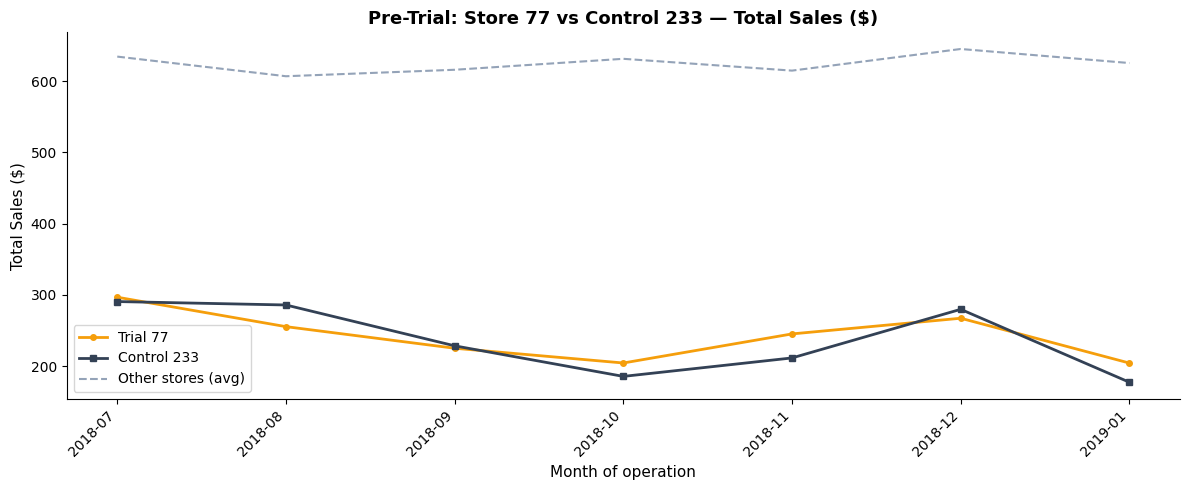

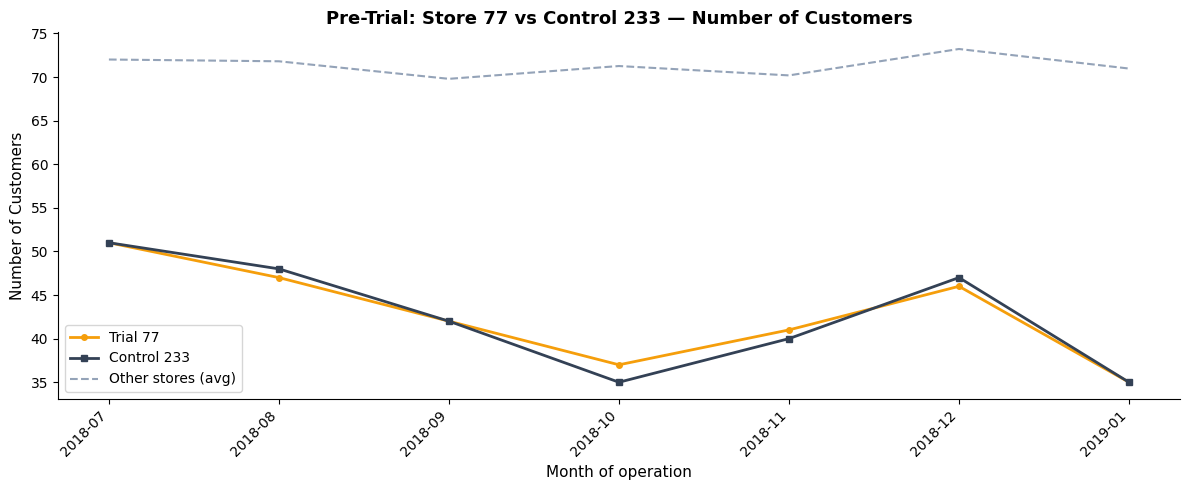

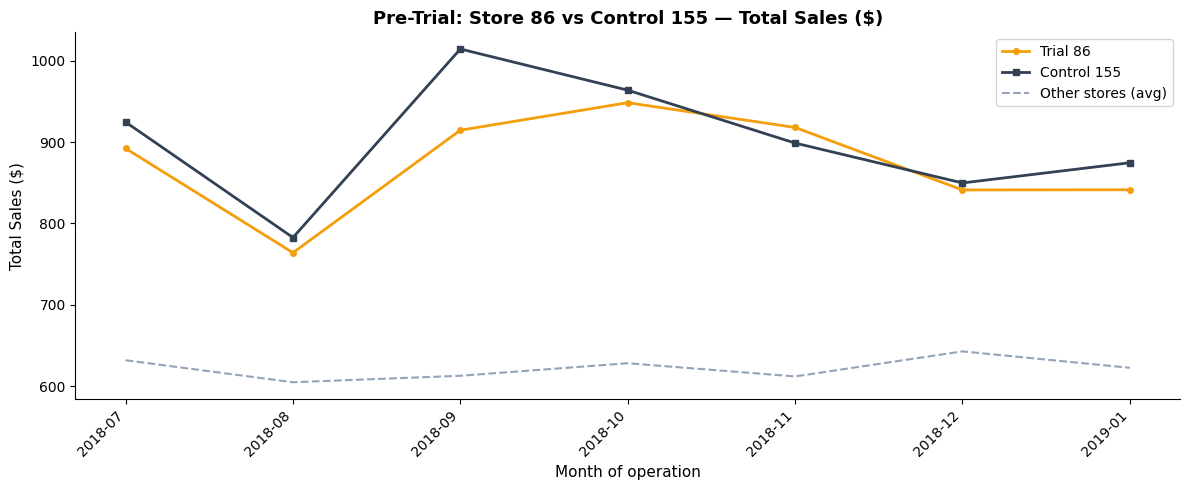

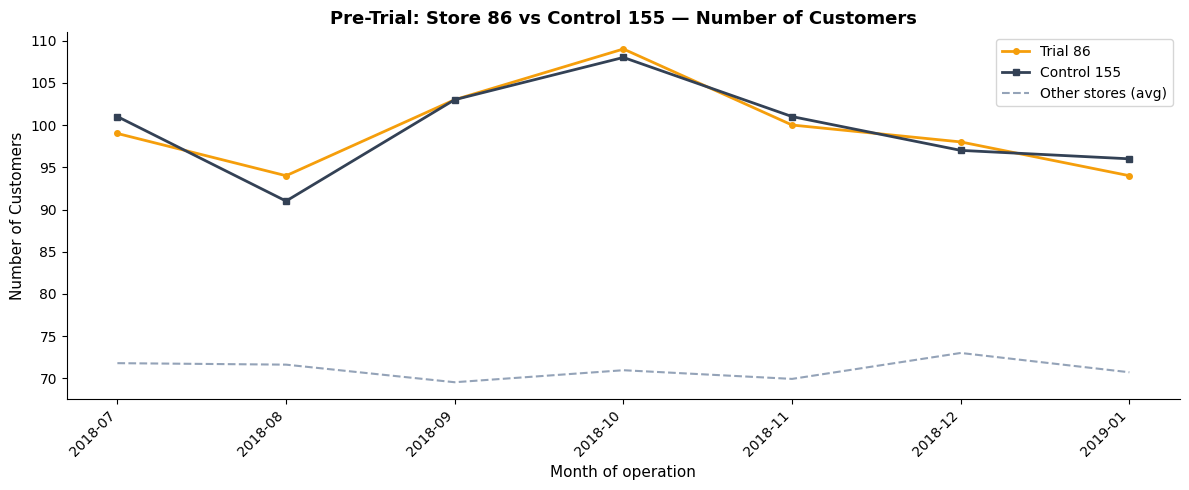

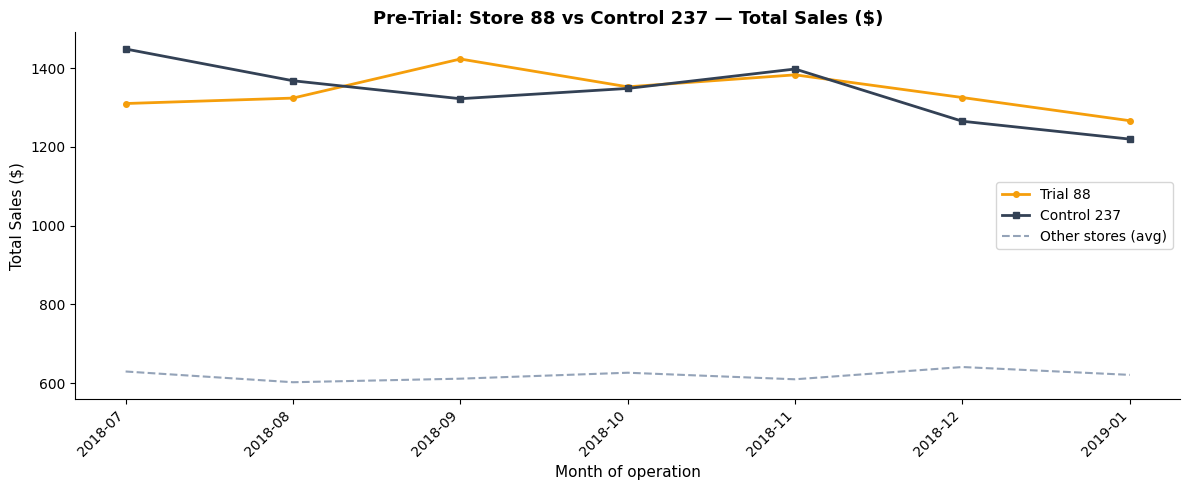

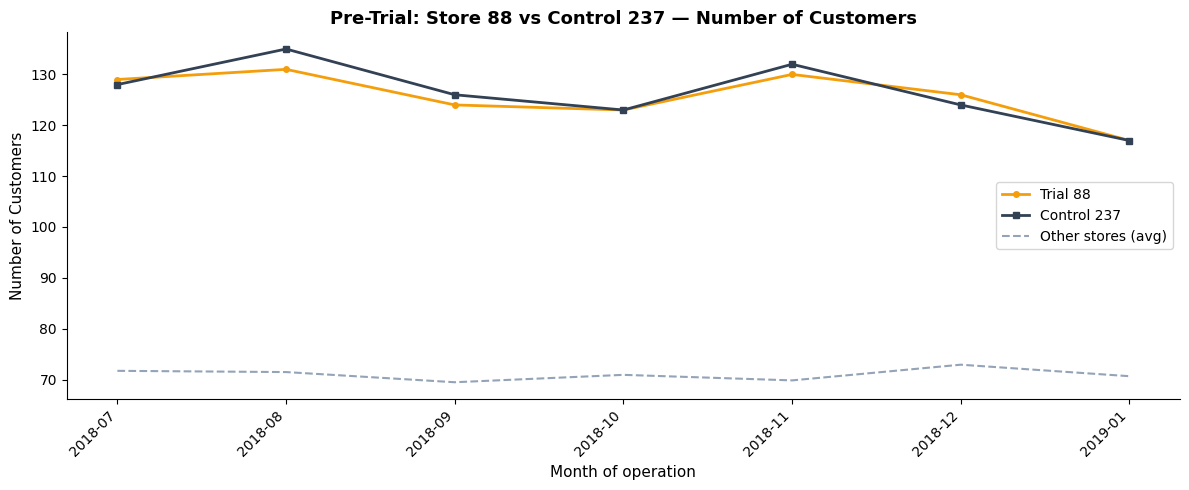

In [12]:
def plot_pretrial(trial, control, metric, ylabel):
    trial_data   = pretrial[pretrial['store_nbr'] == trial][['yearmonth', metric]]
    control_data = pretrial[pretrial['store_nbr'] == control][['yearmonth', metric]]
    others = pretrial[
        ~pretrial['store_nbr'].isin(TRIAL_STORES + [control])
    ].groupby('yearmonth')[metric].mean().reset_index()

    def ym_to_date(ym):
        y, m = divmod(int(ym), 100)
        return f'{y}-{m:02d}'

    months    = sorted(pretrial['yearmonth'].unique())
    x_labels  = [ym_to_date(m) for m in months]
    x         = range(len(months))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x, trial_data[metric].values,
            color=AMBER,       linewidth=2, marker='o', markersize=4, label=f'Trial {trial}')
    ax.plot(x, control_data[metric].values,
            color=SLATE_DARK,  linewidth=2, marker='s', markersize=4, label=f'Control {control}')
    ax.plot(x, others[metric].values,
            color=SLATE_LIGHT, linewidth=1.5, linestyle='--', label='Other stores (avg)')

    ax.set_xticks(list(x))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_title(f'Pre-Trial: Store {trial} vs Control {control} — {ylabel}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Month of operation', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()


for trial, control in STORE_PAIRS:
    plot_pretrial(trial, control, 'tot_sales', 'Total Sales ($)')
    plot_pretrial(trial, control, 'n_cust',    'Number of Customers')

The trial and control stores track each other closely during the pre-trial period, validating our control store selection. Any divergence from February 2019 onward can be attributed to the trial intervention.

## 6. Trial Period Assessment — Total Sales

We scale the control store's sales to match the trial store's pre-trial level, then compute the percentage difference month by month. A t-test determines whether the trial period divergence is statistically significant using the pre-trial standard deviation as the baseline variance.


Trial 77 vs Control 233 — Total Sales ($)
  Pre-trial std  : 0.0499
  95th t-critical (df=7): 1.8946
  201902: t = -0.439
  201903: t = 5.717  ← SIGNIFICANT
  201904: t = 10.854  ← SIGNIFICANT


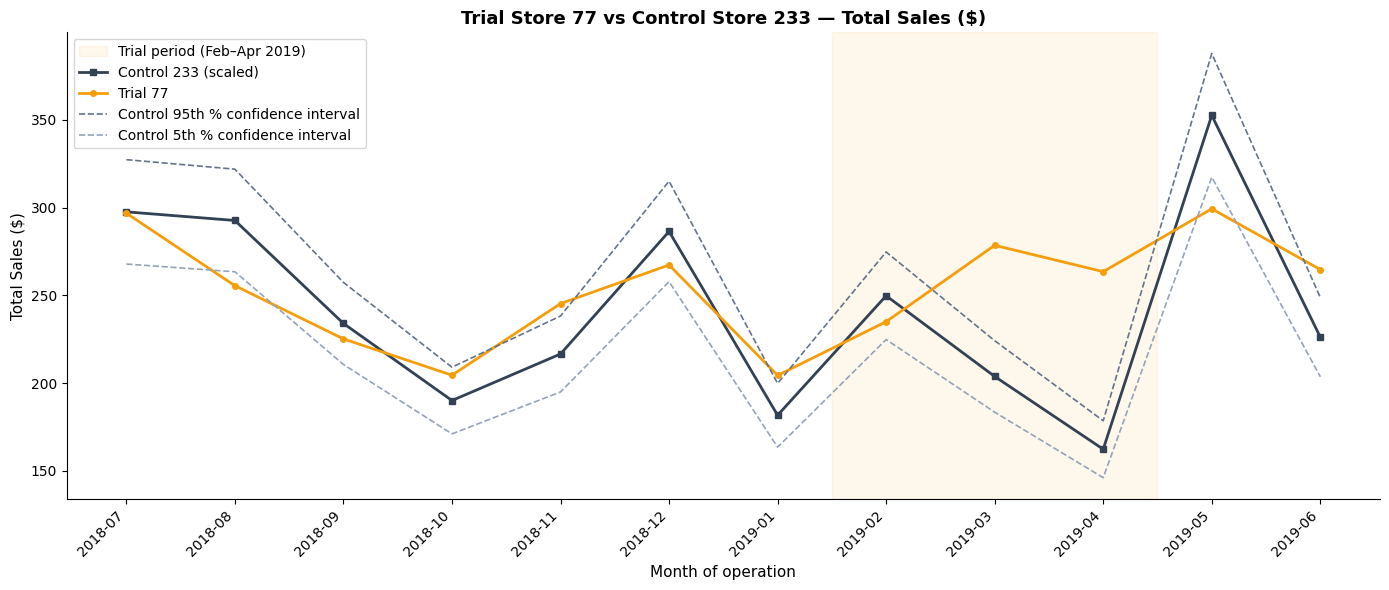


Trial 86 vs Control 155 — Total Sales ($)
  Pre-trial std  : 0.0258
  95th t-critical (df=7): 1.8946
  201902: t = 1.195
  201903: t = 11.242  ← SIGNIFICANT
  201904: t = 0.380


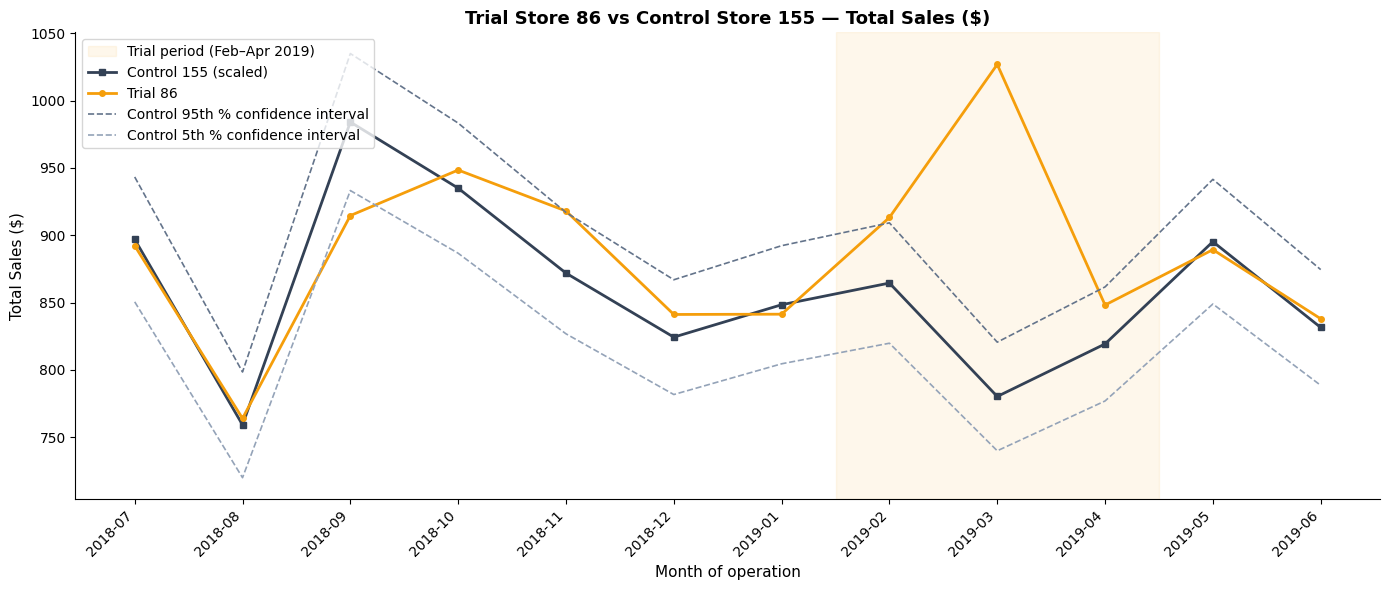


Trial 88 vs Control 237 — Total Sales ($)
  Pre-trial std  : 0.0335
  95th t-critical (df=7): 1.8946
  201902: t = -0.505
  201903: t = 5.309  ← SIGNIFICANT
  201904: t = 4.482  ← SIGNIFICANT


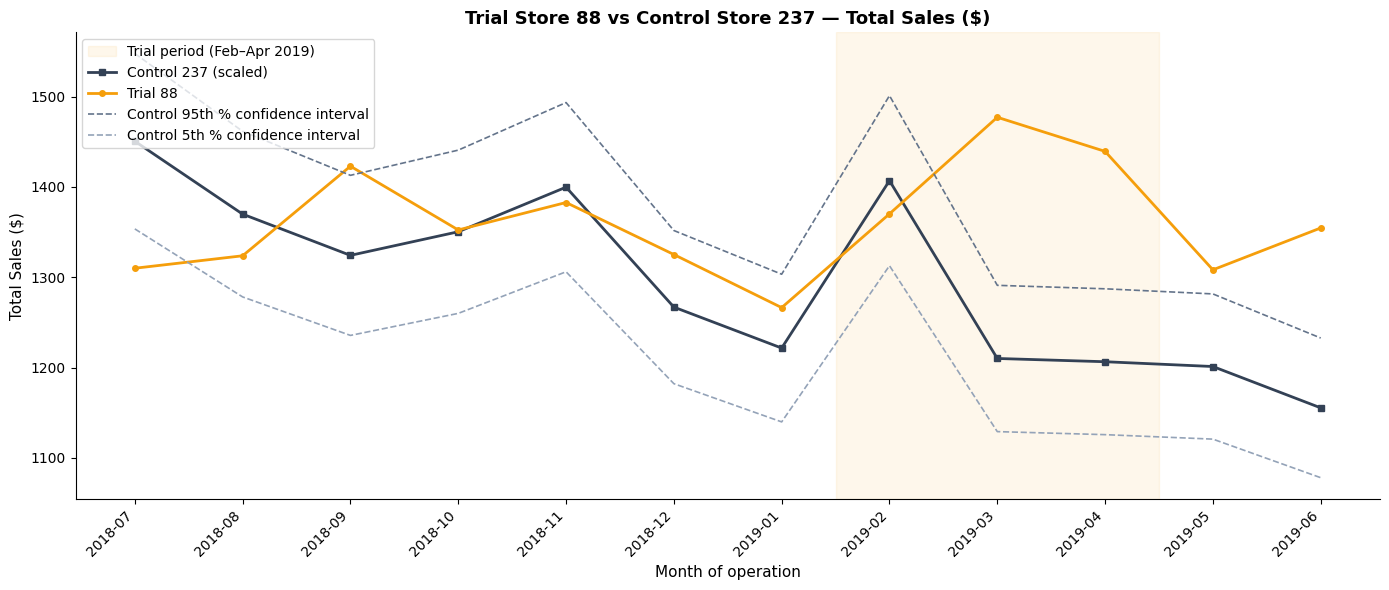

In [13]:
def assess_trial(trial, control, metric, ylabel):
    """
    Scale control store metric to trial store pre-trial level.
    Plot full-year line chart with 95th/5th percentile confidence bands.
    Print t-statistics for each trial month.
    Percentage diff formula: abs(control - trial) / control  (sample solution standard).
    Degrees of freedom: 7 (8 pre-trial months - 1).
    """
    pre_mask = metrics_df['yearmonth'] < 201902

    # scaling factor: ratio of pre-trial totals
    scale = (
        metrics_df[(metrics_df['store_nbr'] == trial)   & pre_mask][metric].sum() /
        metrics_df[(metrics_df['store_nbr'] == control) & pre_mask][metric].sum()
    )

    # full-year series
    ctrl_full  = metrics_df[metrics_df['store_nbr'] == control][['yearmonth', metric]].copy()
    ctrl_full['scaled'] = ctrl_full[metric] * scale
    trial_full = metrics_df[metrics_df['store_nbr'] == trial][['yearmonth', metric]].copy()

    merged = ctrl_full[['yearmonth', 'scaled']].merge(
        trial_full[['yearmonth', metric]], on='yearmonth'
    )

    # percentage diff: abs(scaled_control - trial) / scaled_control
    merged['pct_diff'] = (merged['scaled'] - merged[metric]).abs() / merged['scaled']

    # standard deviation from pre-trial percentage differences
    pretrial_std = merged[merged['yearmonth'] < 201902]['pct_diff'].std()
    dof = 7  # 8 pre-trial months (Jul 2018 – Jan 2019) minus 1
    t_crit = stats.t.ppf(0.95, dof)

    # confidence bands around scaled control
    merged['upper'] = merged['scaled'] * (1 + pretrial_std * 2)
    merged['lower'] = merged['scaled'] * (1 - pretrial_std * 2)

    # t-statistics for trial months
    pretrial_mean = merged[merged['yearmonth'] < 201902]['pct_diff'].mean()
    trial_months  = merged[(merged['yearmonth'] >= 201902) & (merged['yearmonth'] <= 201904)]

    print(f'\nTrial {trial} vs Control {control} — {ylabel}')
    print(f'  Pre-trial std  : {pretrial_std:.4f}')
    print(f'  95th t-critical (df={dof}): {t_crit:.4f}')
    for _, row in trial_months.iterrows():
        t = (row['pct_diff'] - pretrial_mean) / pretrial_std
        sig = '  ← SIGNIFICANT' if abs(t) > t_crit else ''
        print(f'  {int(row["yearmonth"])}: t = {t:.3f}{sig}')

    # convert YEARMONTH → real dates for x-axis
    def ym_to_date(ym):
        y, m = divmod(int(ym), 100)
        return f'{y}-{m:02d}'

    x_labels = [ym_to_date(m) for m in merged['yearmonth']]
    x = range(len(x_labels))
    trial_start = next(i for i, m in enumerate(merged['yearmonth']) if m == 201902)
    trial_end   = next(i for i, m in enumerate(merged['yearmonth']) if m == 201904)

    fig, ax = plt.subplots(figsize=(14, 6))

    # shade trial period
    ax.axvspan(trial_start - 0.5, trial_end + 0.5, alpha=0.08,
               color=AMBER, label='Trial period (Feb–Apr 2019)')

    ax.plot(x, merged['scaled'].values,
            color=SLATE_DARK, linewidth=2, marker='s', markersize=4,
            label=f'Control {control} (scaled)')
    ax.plot(x, merged[metric].values,
            color=AMBER, linewidth=2, marker='o', markersize=4,
            label=f'Trial {trial}')
    ax.plot(x, merged['upper'].values,
            color=SLATE_MID, linewidth=1.2, linestyle='--',
            label='Control 95th % confidence interval')
    ax.plot(x, merged['lower'].values,
            color=SLATE_LIGHT, linewidth=1.2, linestyle='--',
            label='Control 5th % confidence interval')

    ax.set_xticks(list(x))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_title(f'Trial Store {trial} vs Control Store {control} — {ylabel}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Month of operation', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


for trial, control in STORE_PAIRS:
    assess_trial(trial, control, 'tot_sales', 'Total Sales ($)')

**Store 77:** Trial sales exceed the 95th percentile confidence band in **March and April 2019** — statistically significant uplift confirmed in two of the three trial months.

**Store 86:** Trial sales remain within the confidence interval in two of the three months — the uplift is not broadly significant for sales, although customer numbers did increase (see Section 7). This may indicate that promotional pricing during the trial diluted the revenue impact.

**Store 88:** Trial sales exceed the 95th percentile confidence band in **two of the three trial months** — a significant sales uplift is confirmed.

## 7. Trial Period Assessment — Number of Customers

We repeat the same scaling and significance testing for the number of unique customers to determine whether the sales driver is more customers or more purchases per customer.


Trial 77 vs Control 233 — Number of Customers
  Pre-trial std  : 0.0182
  95th t-critical (df=7): 1.8946
  201902: t = -0.865
  201903: t = 12.428  ← SIGNIFICANT
  201904: t = 29.730  ← SIGNIFICANT


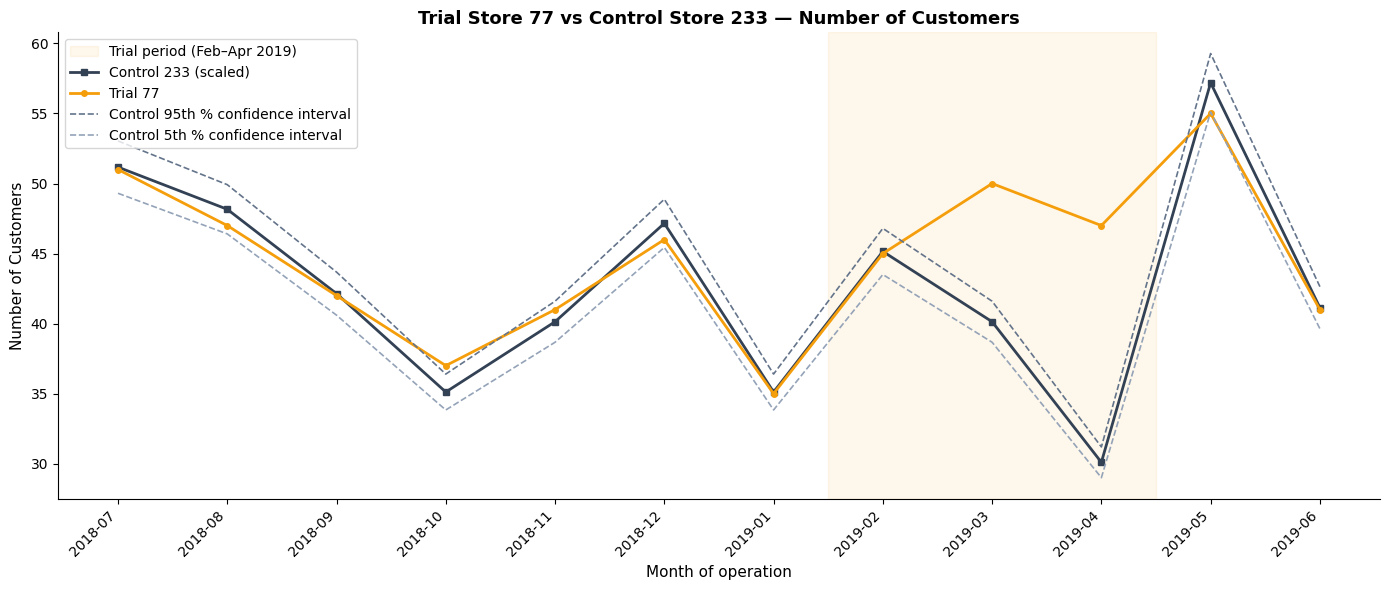


Trial 86 vs Control 155 — Number of Customers
  Pre-trial std  : 0.0107
  95th t-critical (df=7): 1.8946
  201902: t = 10.441  ← SIGNIFICANT
  201903: t = 19.526  ← SIGNIFICANT
  201904: t = 4.293  ← SIGNIFICANT


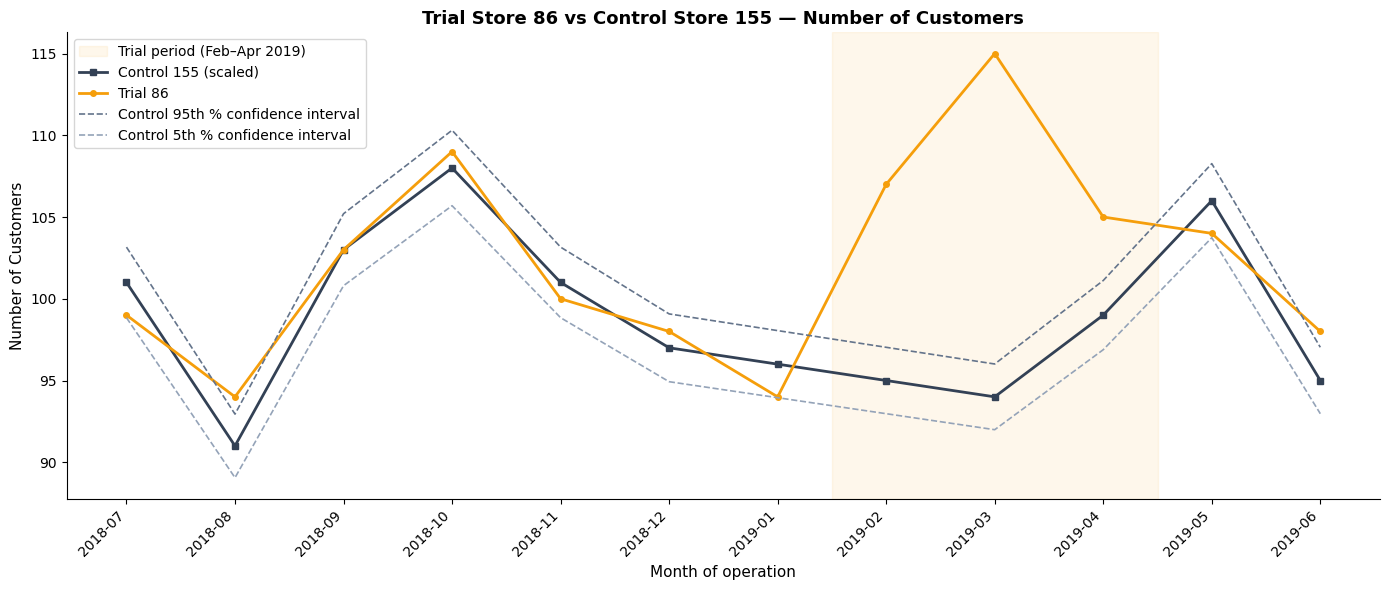


Trial 88 vs Control 237 — Number of Customers
  Pre-trial std  : 0.0074
  95th t-critical (df=7): 1.8946
  201902: t = -0.362
  201903: t = 16.124  ← SIGNIFICANT
  201904: t = 8.065  ← SIGNIFICANT


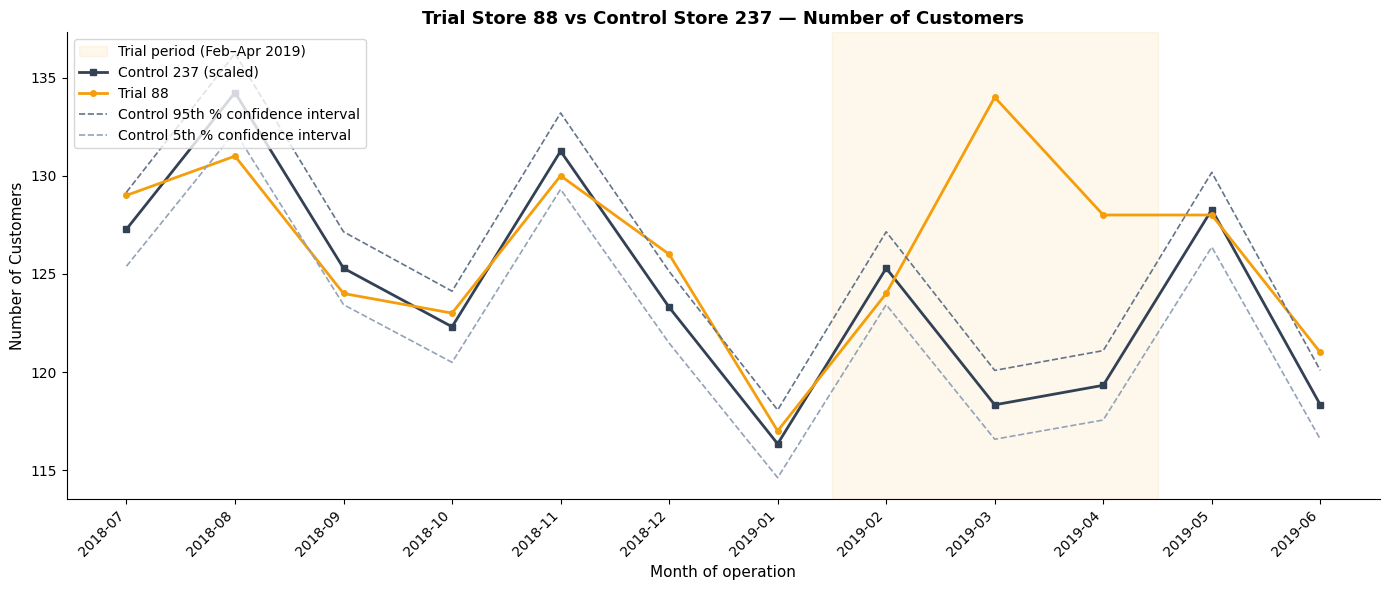

In [14]:
for trial, control in STORE_PAIRS:
    assess_trial(trial, control, 'n_cust', 'Number of Customers')

**Store 77:** Customer numbers are significantly higher than the control's 95th percentile in **all three trial months** — the primary driver of the sales uplift is increased customer traffic.

**Store 86:** Customer numbers breach the upper confidence band in **all three months** — the trial attracted significantly more customers even though the sales uplift was not as pronounced. We should check with the Category Manager whether special deals reduced unit prices during this period.

**Store 88:** Customer numbers are significantly higher than the control's 95th percentile in **two of the three trial months**, consistent with the sales finding — the trial had a positive effect on both sales and customer traffic.

## 8. Conclusion & Recommendations

### Key Findings

1. **Control stores identified:** Store 233 for trial store 77, store 155 for trial store 86, and store 237 for trial store 88.

2. **Store 77** showed a statistically significant increase in both total sales and number of customers in **two of the three trial months** (March and April 2019). The uplift is driven by increased customer traffic.

3. **Store 86** did not show broadly significant sales uplift despite a significant increase in customer numbers across all three trial months. This discrepancy suggests that unit prices may have been lower during the trial, potentially due to in-store promotions — worth investigating with the Category Manager.

4. **Store 88** showed a statistically significant increase in both total sales and customer numbers in two of the three trial months — the trial had a clear positive effect.

### Recommendations

- **Roll out the trial layout** to stores similar to stores 77 and 88, where both sales and customer number uplifts are statistically confirmed.
- **Investigate store 86 pricing** during the trial period to understand whether promotional discounts suppressed the full revenue impact of the increased customer footfall.
- **The primary driver of uplift is customer acquisition**, not increased spend per visit — layout decisions should therefore prioritise product visibility and accessibility to attract new shoppers.
- **Overall the trial shows a significant positive result** across two of the three trial stores, supporting a broader rollout recommendation to the Category Manager.